# Exploration de MediQAI

MediQAI est un jeu de données français de questions-réponses médicales conçu pour évaluer les capacités des modèles de langage en matière de rappel factuel et de raisonnement clinique. 

Contenu :
- 32 603 questions médicales francophones
- 41 spécialités médicales
- Questions de connaissance
- Questions de raisonnement
- Questions ouvertes
- QCM à réponse unique
- QCM à réponses multiples 

Sous-ensembles :
- mcqu : Multiple Choice Question Unique
- mcqm : Multiple Choice Question Multiple
- oeq : Open Ended Questions

In [18]:
# Installation si nécessaire
# !pip install datasets pandas matplotlib seaborn pyarrow

## Importation

Le jeu de données provient de la base Huggin face 

In [19]:
from huggingface_hub import hf_hub_download
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset


In [20]:
DATASET_NAME = "ANR-MALADES/MediQAl"

configs = ["mcqu", "mcqm", "oeq"]

datasets = {
    config: load_dataset(DATASET_NAME, name=config)
    for config in configs
}

In [21]:
# Afficher la structure générale
for name, dataset in datasets.items():
    print(f"\n===== {name.upper()} =====")
    print(dataset)


===== MCQU =====
DatasetDict({
    train: Dataset({
        features: ['id', 'clinical_case', 'question', 'answer_a', 'answer_b', 'answer_c', 'answer_d', 'answer_e', 'correct_answers', 'task', 'medical_subject', 'question_type'],
        num_rows: 10113
    })
    validation: Dataset({
        features: ['id', 'clinical_case', 'question', 'answer_a', 'answer_b', 'answer_c', 'answer_d', 'answer_e', 'correct_answers', 'task', 'medical_subject', 'question_type'],
        num_rows: 2561
    })
    test: Dataset({
        features: ['id', 'clinical_case', 'question', 'answer_a', 'answer_b', 'answer_c', 'answer_d', 'answer_e', 'correct_answers', 'task', 'medical_subject', 'question_type'],
        num_rows: 4343
    })
})

===== MCQM =====
DatasetDict({
    train: Dataset({
        features: ['id', 'clinical_case', 'question', 'answer_a', 'answer_b', 'answer_c', 'answer_d', 'answer_e', 'correct_answers', 'task', 'medical_subject', 'question_type'],
        num_rows: 5767
    })
    validati

In [22]:
# Conversion en DataFrames pandas

dfs = {}

for config_name, dataset_dict in datasets.items():
    for split_name, split_dataset in dataset_dict.items():
        key = f"{config_name}_{split_name}"
        dfs[key] = split_dataset.to_pandas()

        print(
            f"{config_name.upper()} | "
            f"split: {split_name} | "
            f"shape: {dfs[key].shape}"
        )

MCQU | split: train | shape: (10113, 12)
MCQU | split: validation | shape: (2561, 12)
MCQU | split: test | shape: (4343, 12)
MCQM | split: train | shape: (5767, 12)
MCQM | split: validation | shape: (1466, 12)
MCQM | split: test | shape: (3384, 12)
OEQ | split: test | shape: (4969, 7)


In [23]:
# Aperçu des colonnes

for name, df in dfs.items():
    print(f"\n===== Colonnes {name.upper()} =====")
    print(df.columns.tolist())
    display(df.head())


===== Colonnes MCQU_TRAIN =====
['id', 'clinical_case', 'question', 'answer_a', 'answer_b', 'answer_c', 'answer_d', 'answer_e', 'correct_answers', 'task', 'medical_subject', 'question_type']


,id,clinical_case,question,answer_a,answer_b,answer_c,answer_d,answer_e,correct_answers,task,medical_subject,question_type
0,7543,"Monsieur R. âgé de 37 ans, forestier de son mé...",Au sujet des vaccinations :,Le vaccin contre la fièvre jaune est obligatoire,Le vaccin contre la fièvre jaune peut se faire...,Le vaccin contre le choléra est un vaccin qui ...,Le vaccin contre l'hépatite B est conseillé ma...,Les vaccinations contre le tétanos et la polio...,A,QCU,Infectious Diseases,Understanding
1,10495,None,"Devant une tuméfaction cervicale médiane, juxt...",Kyste dermoïde,Laryngocèle,Kyste du tractus thyréoglosse,Grenouillette sublinguale,Lithiase salivaire,C,QCU,Otorhinolaryngology (ENT),Understanding
2,17342,Une jeune femme de 24 ans vous consulte pour a...,Le traitement de cette patiente fait appel à :,Chirurgie en urgence,Iode radio-actif en urgence,Iode radio-actif en préparation à la chirurgie,Administration d'antithyroïdiens,Aucun de ces traitements,D,QCU,Endocrinology and Metabolism,Reasoning
3,22883,"Un nouveau-né de sexe masculin, âgé de 3 jours...",Chez ce nouveau-né le bilan biologique à montr...,Ictère par Incompatibilité Rhésus,Ictère par déficit en G6PD,ictère infectieux,Ictère par incompatibilité ABO,Ictère Infectieux,D,QCU,Pediatrics,Understanding
4,17514,Un homme de 63 ans est hospitalisé pour des do...,Pour confirmer le diagnostic de maladie d'Addi...,Test de stimulation par la 1.24 corticotrophin...,Test de freinage par la dexaméthasone,Test de stimulation de l'activité rénine plasm...,Test de restriction hydrique,Scintigraphie surrénale à l'iodocholestérol,A,QCU,Endocrinology and Metabolism,Reasoning



===== Colonnes MCQU_VALIDATION =====
['id', 'clinical_case', 'question', 'answer_a', 'answer_b', 'answer_c', 'answer_d', 'answer_e', 'correct_answers', 'task', 'medical_subject', 'question_type']


,id,clinical_case,question,answer_a,answer_b,answer_c,answer_d,answer_e,correct_answers,task,medical_subject,question_type
0,9940,None,L'amblyopie fonctionnelle se définit comme :,Une déviation des axes oculaires l'un par rapp...,Une paralysie de la motricité pupillaire,Une faible acuité visuelle sans cause organiqu...,Une perte du champ visuel périphérique,Aucune des définitions citées,C,QCU,Ophthalmology,Understanding
1,14132,None,"De 1967 à 1972, un groupe de 300 ouvriers expo...","0,1","0,2","1,5",5,6,D,QCU,Epidemiology,Reasoning
2,23706,None,(cochez la réponse fausse) Un syndrome confusi...,De la stupeur,De mutisme,D'agitation,De désorientation,De discordance,E,QCU,Psychiatry,Understanding
3,25123,None,(cochez la réponse fausse) Le diagnostic préco...,Des marbrures précoces commençant aux genoux,Une hypotension artérielle précoce,Une tachycardie sinusale,Une obnubilation souvent au premier plan chez ...,Une alcalose métabolique,E,QCU,Physiology,Understanding
4,3365,None,Au cours de la détection d'anticorps anti-nucl...,Fluorescence homogène,Fluorescence mouchetée,Fluorescence homogène et mouchetée,Fluorescence périphérique (cerclée),Fluorescence nucléolaire,D,QCU,Rheumatology,Understanding



===== Colonnes MCQU_TEST =====
['id', 'clinical_case', 'question', 'answer_a', 'answer_b', 'answer_c', 'answer_d', 'answer_e', 'correct_answers', 'task', 'medical_subject', 'question_type']


...

,id,clinical_case,question,answer_a,answer_b,answer_c,answer_d,answer_e,correct_answers,task,medical_subject,question_type
0,19099,Un patient agé de 76 ans se présente avec un t...,Les actions pharmacodynamiques de la Dobutamin...,Bronchodilatation à faibles doses,Tachycardie à fortes doses,Stimulation inotrope dose dépendante,Action bathmotrope dose dépendante,Vasodilatation artérielle périphérique à faibl...,"B,C,D",QCM,Pharmacology,Understanding
1,4183,None,Citer la ou les thérapeutiques utilisées dans ...,La vagotomie tronculaire + pyloroplastie,La gastrectomie pôlaire supérieure,La myotomie extramuqueuse de Heller,Les dilatations pneumatiques,Une fundoplicature de l'oesophage,"C,D",QCM,Hepato-Gastroenterology,Understanding
2,10287,Un homme se présente après avoir reçu de l'eau...,Quel(s) est (sont) le(s) geste(s) thérapeutiqu...,Un nettoyage des culs de sac palpébraux,Un lavage des voies lacrymales,Une instillation d'Atropine,Une antibiothérapie locale,Une injection sous-conjonctivale de vasodilata...,"A,B,C,D,E",QCM,Ophthalmology,Understanding
3,16781,Un homme de 38 ans a depuis quelques semaines ...,Le ou les diagnostics qu'il convient de discut...,Hyperaldostéronisme primaire,Sténose d'une artère rénale,Phéochromocytome,Tumeur sécrétant de la rénine,Coarctation de l'aorte,"A,B,D,E",QCM,Cardiology,Reasoning
4,386,None,"En diminuant la consommation de tabac, on peut...",Cancer du corps de l'utérus,Maladies cardio-vasculaires,Cancer de l'estomac,Cancer du poumon,Cancer de la vessie,"B,D,E",QCM,Pathological Anatomy,Understanding



===== Colonnes MCQM_TEST =====
['id', 'clinical_case', 'question', 'answer_a', 'answer_b', 'answer_c', 'answer_d', 'answer_e', 'correct_answers', 'task', 'medical_subject', 'question_type']


,id,clinical_case,question,answer_a,answer_b,answer_c,answer_d,answer_e,correct_answers,task,medical_subject,question_type
0,21347,"Un homme de 52 ans, éthylique chronique, consu...","Parmi les maladies suivantes, quelle(s) est(so...",Hyperthyroïdie,Tumeur carcinoïde entraînant un syndrome carci...,Cancer médullaire du corps thyroïde,Déconjugaision des sels biliaires dans l'iléon,Diabète avec neuropathie végétative,"A,B,C,D,E",QCM,Hepato-Gastroenterology,Understanding
1,3208,Un diagnostic de myélome est porté chez un hom...,"Parmi les critères suivants, lequel ou lesquel...",VS = 120,Uricémie à 660 micromol/l,Hémoglobine : 81 g/l,Créatinémie : 180 micromol/l,"Protéinurie de Bence-Jones : 4,3 g/24 h.","C,D,E",QCM,Hematology,Reasoning
2,1120,None,Devant une tachycardie ventriculaire soutenue ...,Les manoeuvres vagales,La lidocaïne,Les digitaliques,Le choc électrique externe sous anesthésie gén...,L'isoprotérénol,"B,D",QCM,Cardiology,Understanding
3,12201,None,L'induction enzymatique est une propriété :,De la cimétidine (Tagamet®),Des barbituriques,De la troleandromycine (Tao®),"De la rifampicine (Rifadine®, Rimactan®)",Du clofibrate (Lipavlon®),"B,D",QCM,Pharmacology,Understanding
4,13021,"Mademoiselle S. 22 ans, étudiante, est asthmat...","Au bout de 24 heures, son état s'aggrave. Parm...",L'absence de sédation sous ventoline correctem...,L'existence d'un silence auscultatoire,Une hypercapnie,La notion d'état de mal dans les antécédents,Un peak-flow entre 400 et 500 ml/mn,"A,B,C,D",QCM,Pulmonology,Reasoning



===== Colonnes OEQ_TEST =====
['id', 'clinical_case', 'cc_question_number', 'question', 'answer', 'medical_subject', 'question_type']


,id,clinical_case,cc_question_number,question,answer,medical_subject,question_type
0,1,"Homme, 58 ans, majoration de dyspnée chez un B...",1,Quels sont éléments de gravité au moment de l’...,"FC>125bpm\n Terrain : ATCD de BPCO, insuffisan...",Emergency Medicine,Reasoning
1,2,"Homme, 58 ans, majoration de dyspnée chez un B...",2,Caractérisez en une phrase le tableau syndrom...,Insuffisance respiratoire aiguë / exacerbation...,Emergency Medicine,Reasoning
2,3,"Homme, 58 ans, majoration de dyspnée chez un B...",3,Quelle est l'explication la plus probable de l...,"Signes d’hypercapnie, pas d’effet du traitemen...",Emergency Medicine,Reasoning
3,4,"Homme, 58 ans, majoration de dyspnée chez un B...",4,Où le patient doit-il être hospitalisé ?,"En réanimation, car pas de réponse au traiteme...",Emergency Medicine,Reasoning
4,5,"M. Shoot, 30 ans.\n Agitation à la sortie d’un...",1,Quelle substance a-t-il prise ce soir ? Quels ...,"Cocaïne, qui donne un état d’agitation.\n Sign...",Emergency Medicine,Reasoning


In [24]:
# Informations générales

for name, df in dfs.items():
    print(f"\n===== Infos {name.upper()} =====")
    print(df.info())


===== Infos MCQU_TRAIN =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10113 entries, 0 to 10112
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   id               10113 non-null  object
 1   clinical_case    3935 non-null   object
 2   question         10113 non-null  object
 3   answer_a         10113 non-null  object
 4   answer_b         10113 non-null  object
 5   answer_c         10113 non-null  object
 6   answer_d         10113 non-null  object
 7   answer_e         10113 non-null  object
 8   correct_answers  10113 non-null  object
 9   task             10113 non-null  object
 10  medical_subject  10113 non-null  object
 11  question_type    10113 non-null  object
dtypes: object(12)
memory usage: 948.2+ KB
None

===== Infos MCQU_VALIDATION =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2561 entries, 0 to 2560
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dty

In [25]:
# Valeurs manquantes

for name, df in dfs.items():
    print(f"\n===== Valeurs manquantes {name.upper()} =====")
    missing = df.isna().sum().sort_values(ascending=False)
    display(missing[missing > 0])


===== Valeurs manquantes MCQU_TRAIN =====


clinical_case    6178
dtype: int64


===== Valeurs manquantes MCQU_VALIDATION =====


clinical_case    1562
dtype: int64


===== Valeurs manquantes MCQU_TEST =====


...

clinical_case    919
dtype: int64


===== Valeurs manquantes MCQM_TEST =====


clinical_case    2042
dtype: int64


===== Valeurs manquantes OEQ_TEST =====


cc_question_number    1016
clinical_case         1015
dtype: int64

In [26]:
# Nombre total de questions

summary = []

for name, df in dfs.items():
    summary.append({
        "subset": name,
        "nb_questions": len(df),
        "nb_colonnes": df.shape[1]
    })

summary_df = pd.DataFrame(summary)
display(summary_df)

print("Nombre total de questions :", summary_df["nb_questions"].sum())

,subset,nb_questions,nb_colonnes
0,mcqu_train,10113,12
1,mcqu_validation,2561,12
2,mcqu_test,4343,12
3,mcqm_train,5767,12
4,mcqm_validation,1466,12
5,mcqm_test,3384,12
6,oeq_test,4969,7


Nombre total de questions : 32603


In [27]:
# Longueur des questions

QUESTION_COL = "question"

for name, df in dfs.items():
    if QUESTION_COL in df.columns:
        df["question_length_chars"] = df[QUESTION_COL].astype(str).str.len()
        df["question_length_words"] = df[QUESTION_COL].astype(str).str.split().str.len()
        
        print(f"\n===== Longueur des questions {name.upper()} =====")
        display(df[["question_length_chars", "question_length_words"]].describe())


===== Longueur des questions MCQU_TRAIN =====


,question_length_chars,question_length_words
count,10113.000000,10113.000000
mean,125.974488,19.411846
std,87.228989,13.582392
min,8.000000,2.000000
25%,72.000000,11.000000
50%,101.000000,15.000000
75%,147.000000,22.000000
max,980.000000,164.000000



===== Longueur des questions MCQU_VALIDATION =====


,question_length_chars,question_length_words
count,2561.000000,2561.000000
mean,123.518938,19.005467
std,87.277246,13.474454
min,12.000000,3.000000
25%,72.000000,11.000000
50%,101.000000,15.000000
75%,145.000000,22.000000
max,1486.000000,221.000000



===== Longueur des questions MCQU_TEST =====


...

,question_length_chars,question_length_words
count,1466.000000,1466.000000
mean,94.239427,13.821965
std,52.726734,7.797284
min,9.000000,2.000000
25%,58.000000,9.000000
50%,88.000000,13.000000
75%,119.000000,17.000000
max,494.000000,77.000000



===== Longueur des questions MCQM_TEST =====


,question_length_chars,question_length_words
count,3384.000000,3384.000000
mean,98.086288,14.480496
std,52.786893,7.947521
min,7.000000,2.000000
25%,62.000000,9.000000
50%,91.000000,13.000000
75%,123.000000,18.000000
max,467.000000,73.000000



===== Longueur des questions OEQ_TEST =====


,question_length_chars,question_length_words
count,4969.000000,4969.000000
mean,130.039847,19.404709
std,115.882786,18.428776
min,10.000000,1.000000
25%,65.000000,10.000000
50%,98.000000,14.000000
75%,149.000000,22.000000
max,1545.000000,250.000000


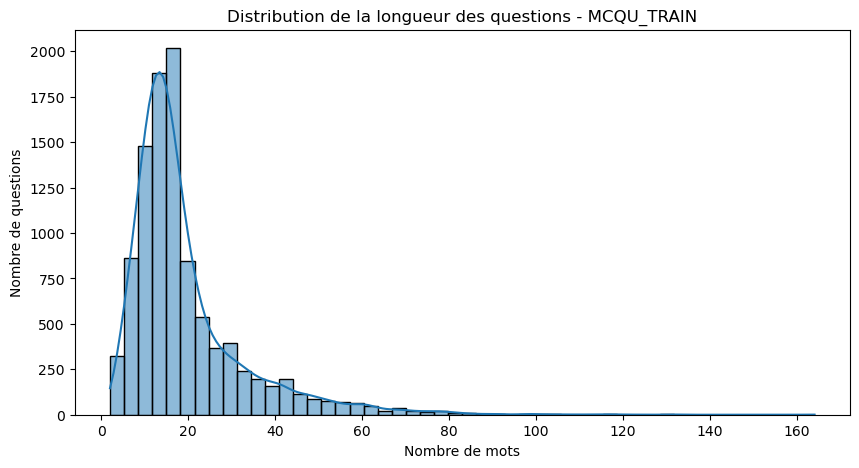

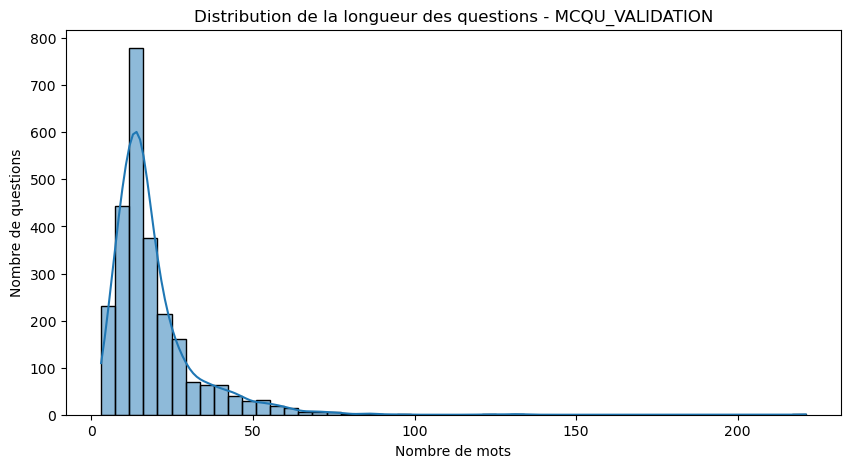

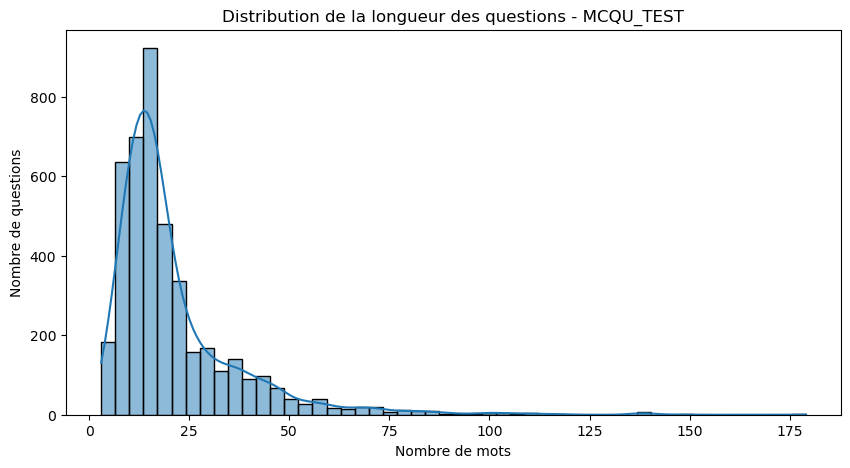

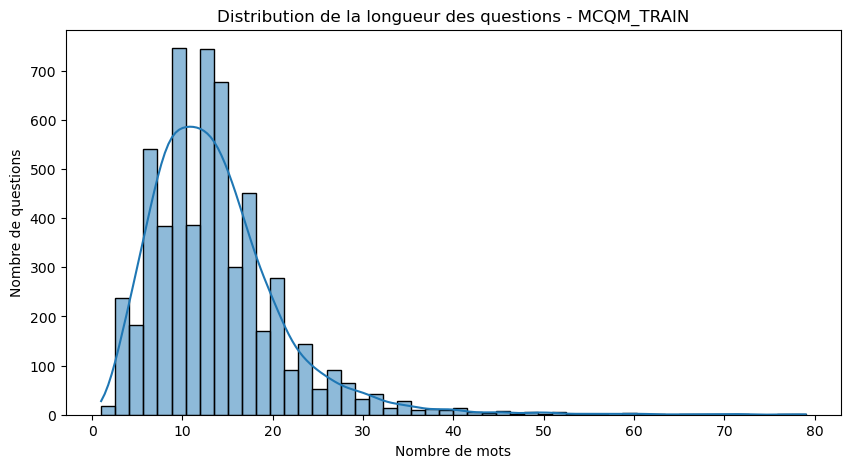

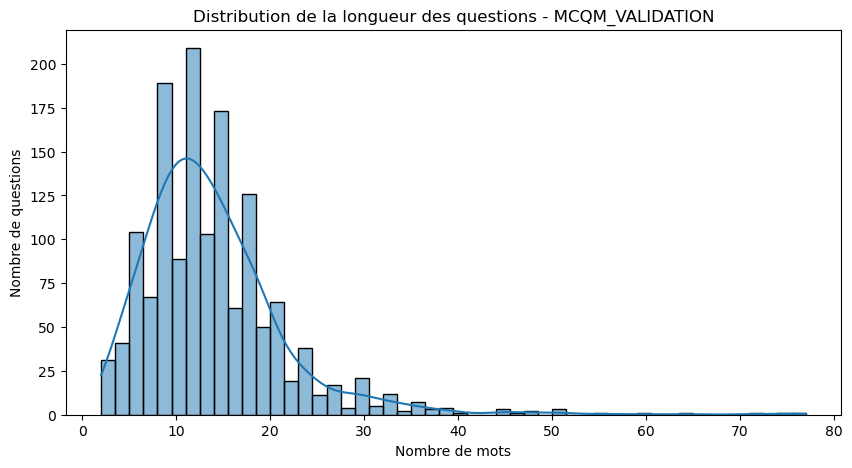

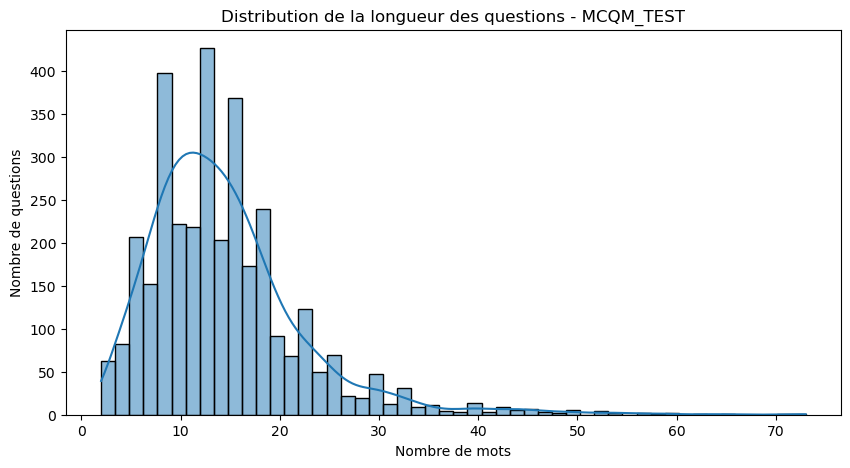

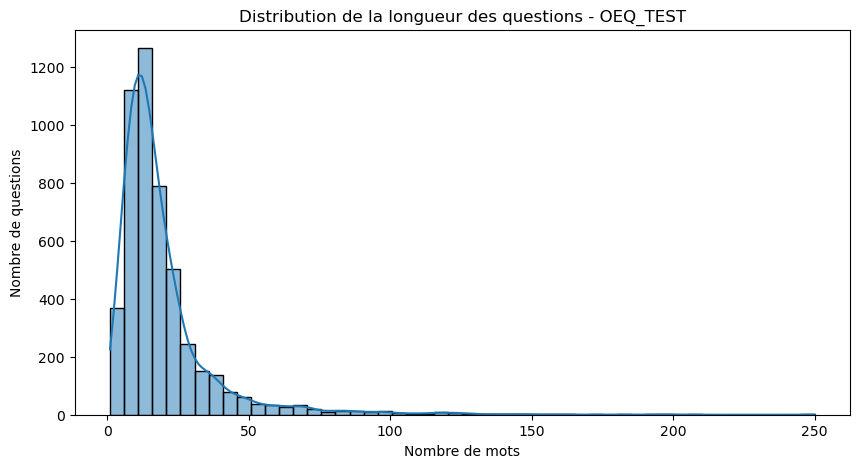

In [28]:
# Distribution des longueurs de questions

for name, df in dfs.items():
    if "question_length_words" in df.columns:
        plt.figure(figsize=(10, 5))
        sns.histplot(df["question_length_words"], bins=50, kde=True)
        plt.title(f"Distribution de la longueur des questions - {name.upper()}")
        plt.xlabel("Nombre de mots")
        plt.ylabel("Nombre de questions")
        plt.show()


===== Répartition des spécialités MCQU_TRAIN | colonne: medical_subject =====


medical_subject
Cardiology                      691
Hepato-Gastroenterology         661
Gynecology and Obstetrics       626
Endocrinology and Metabolism    552
Pulmonology                     535
Hematology                      525
Nephro-Urology                  496
Pediatrics                      467
Psychiatry                      419
Neurology                       394
Rheumatology                    394
Infectious Diseases             390
Otorhinolaryngology (ENT)       333
Orthopedics                     323
Pathological Anatomy            308
Immunology                      297
Ophthalmology                   295
Biochemistry                    291
Dermatology                     289
Microbiology                    271
Name: count, dtype: int64

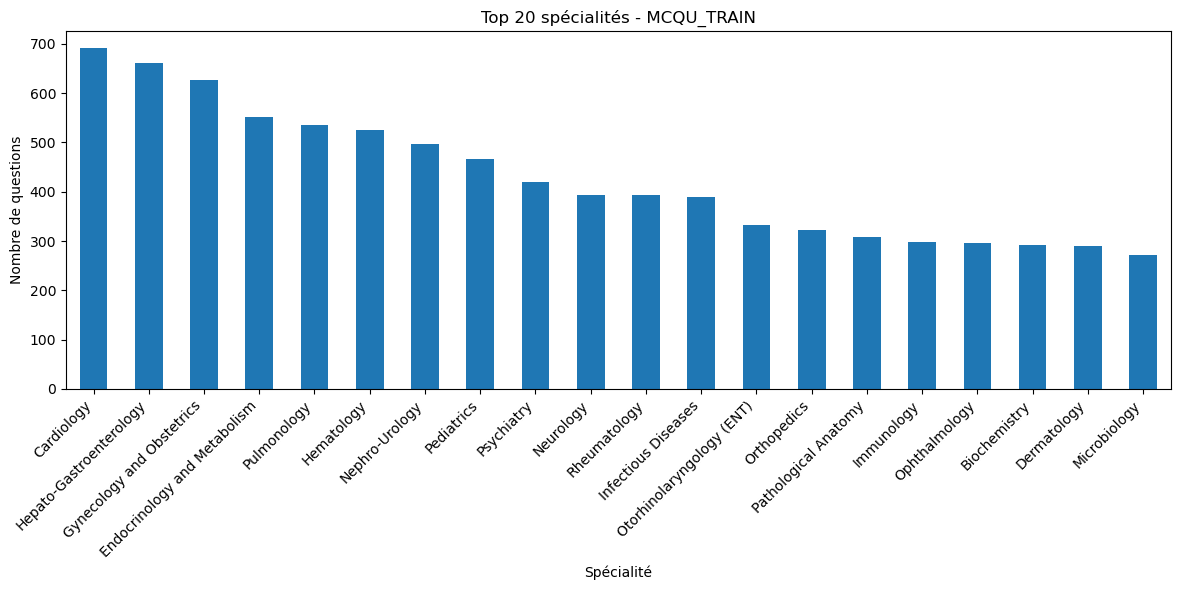


===== Répartition des spécialités MCQU_VALIDATION | colonne: medical_subject =====


medical_subject
Cardiology                      174
Hepato-Gastroenterology         167
Gynecology and Obstetrics       157
Endocrinology and Metabolism    139
Pulmonology                     134
Hematology                      132
Nephro-Urology                  125
Pediatrics                      118
Psychiatry                      106
Rheumatology                    100
Neurology                        99
Infectious Diseases              99
Otorhinolaryngology (ENT)        84
Orthopedics                      82
Pathological Anatomy             78
Immunology                       76
Ophthalmology                    74
Biochemistry                     74
Dermatology                      73
Microbiology                     69
Name: count, dtype: int64

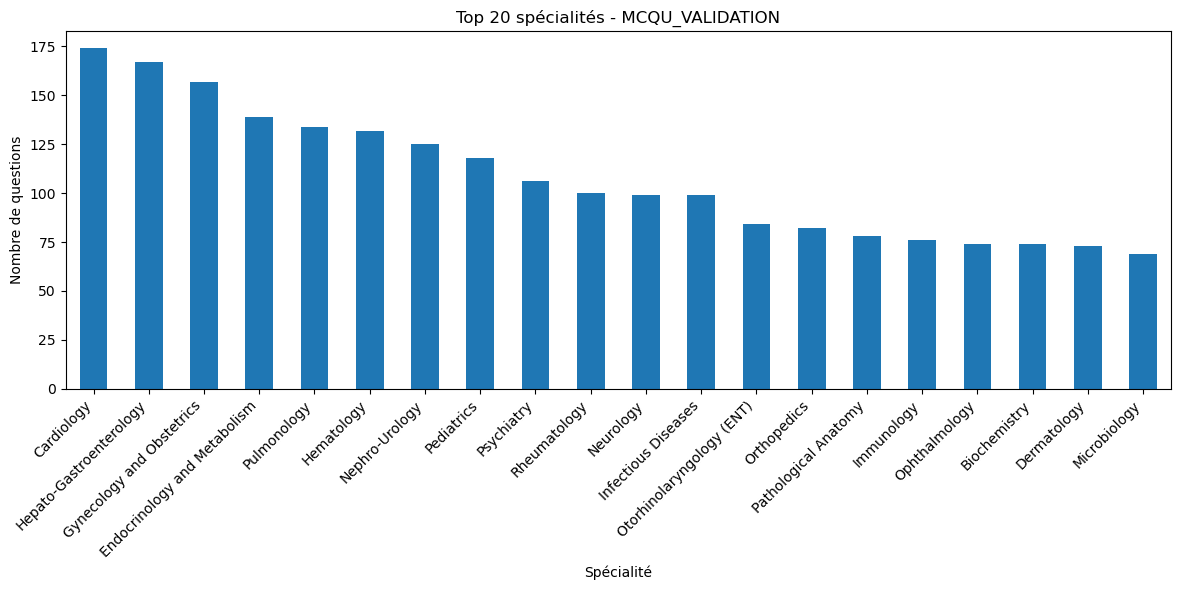


===== Répartition des spécialités MCQU_TEST | colonne: medical_subject =====


medical_subject
Cardiology                          327
Hematology                          317
Gynecology and Obstetrics           280
Hepato-Gastroenterology             278
Pulmonology                         248
Nephro-Urology                      227
Pediatrics                          215
Rheumatology                        209
Endocrinology and Metabolism        207
Infectious Diseases                 192
Neurology                           177
Orthopedics                         172
Psychiatry                          142
Otorhinolaryngology (ENT)           127
Dermatology                         125
Occupational Medicine               107
Biochemistry                        103
Forensic Medicine and Toxicology     99
Epidemiology                         97
Ophthalmology                        95
Name: count, dtype: int64

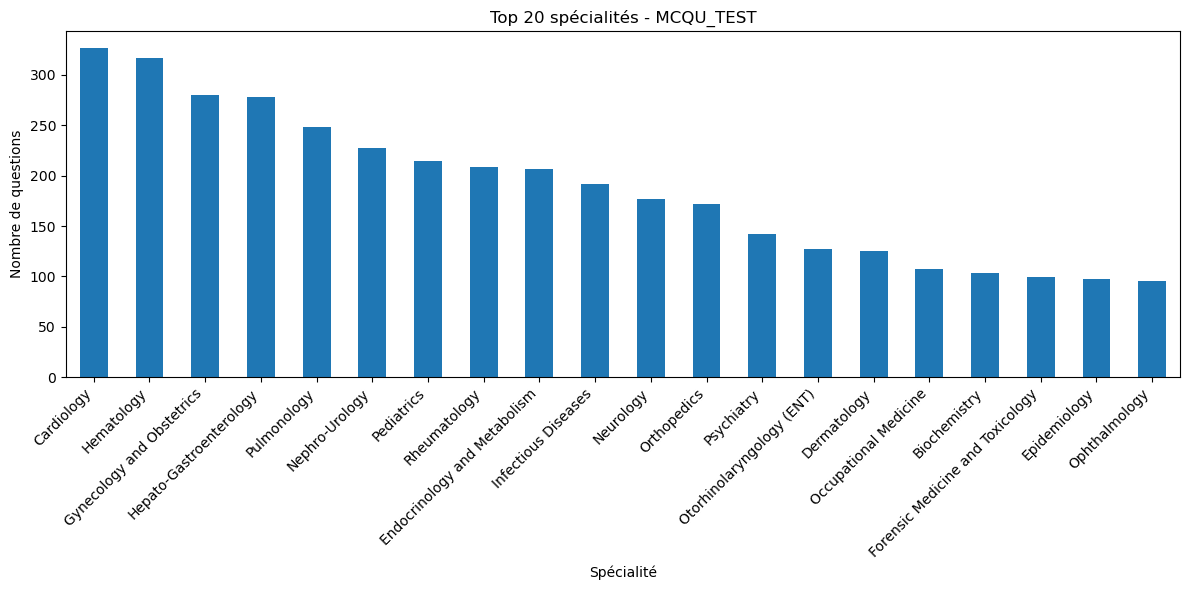


===== Répartition des spécialités MCQM_TRAIN | colonne: medical_subject =====


medical_subject
Cardiology                          395
Hepato-Gastroenterology             395
Pulmonology                         341
Psychiatry                          329
Nephro-Urology                      328
Endocrinology and Metabolism        300
Infectious Diseases                 291
Gynecology and Obstetrics           290
Rheumatology                        289
Hematology                          281
Neurology                           278
Dermatology                         270
Pediatrics                          249
Otorhinolaryngology (ENT)           220
Ophthalmology                       196
Forensic Medicine and Toxicology    172
Immunology                          158
Pharmacology                        147
Biochemistry                        142
Pathological Anatomy                141
Name: count, dtype: int64

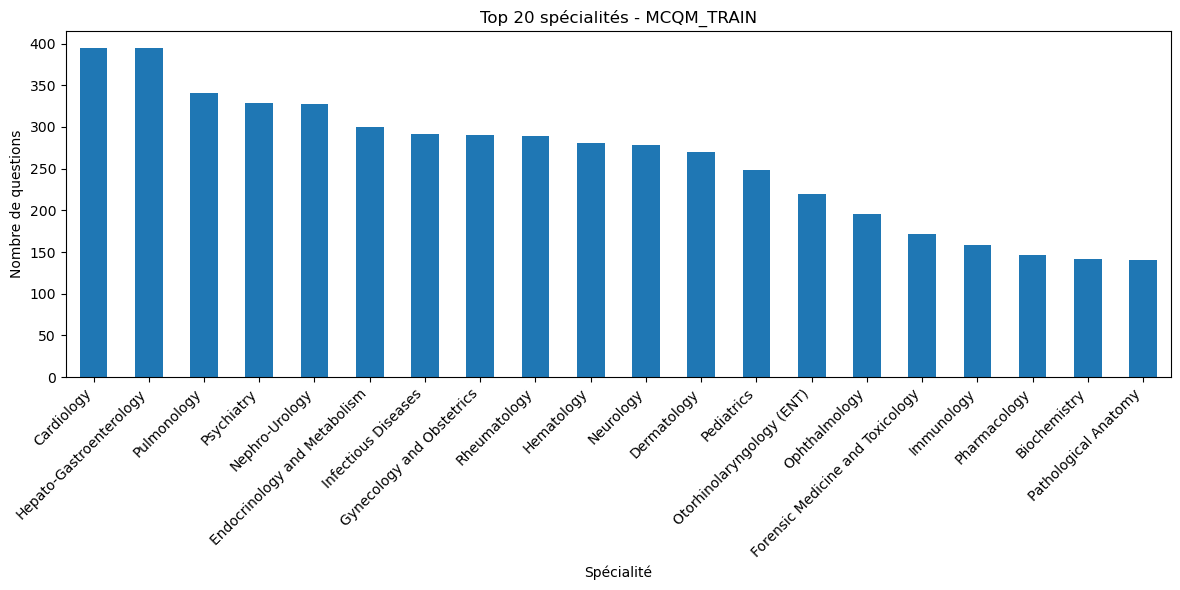


===== Répartition des spécialités MCQM_VALIDATION | colonne: medical_subject =====


medical_subject
Hepato-Gastroenterology             100
Cardiology                          100
Pulmonology                          86
Psychiatry                           84
Nephro-Urology                       84
Endocrinology and Metabolism         75
Infectious Diseases                  74
Gynecology and Obstetrics            73
Rheumatology                         73
Hematology                           71
Neurology                            71
Dermatology                          68
Pediatrics                           64
Otorhinolaryngology (ENT)            56
Ophthalmology                        49
Forensic Medicine and Toxicology     44
Immunology                           40
Biochemistry                         37
Pharmacology                         37
Pathological Anatomy                 36
Name: count, dtype: int64

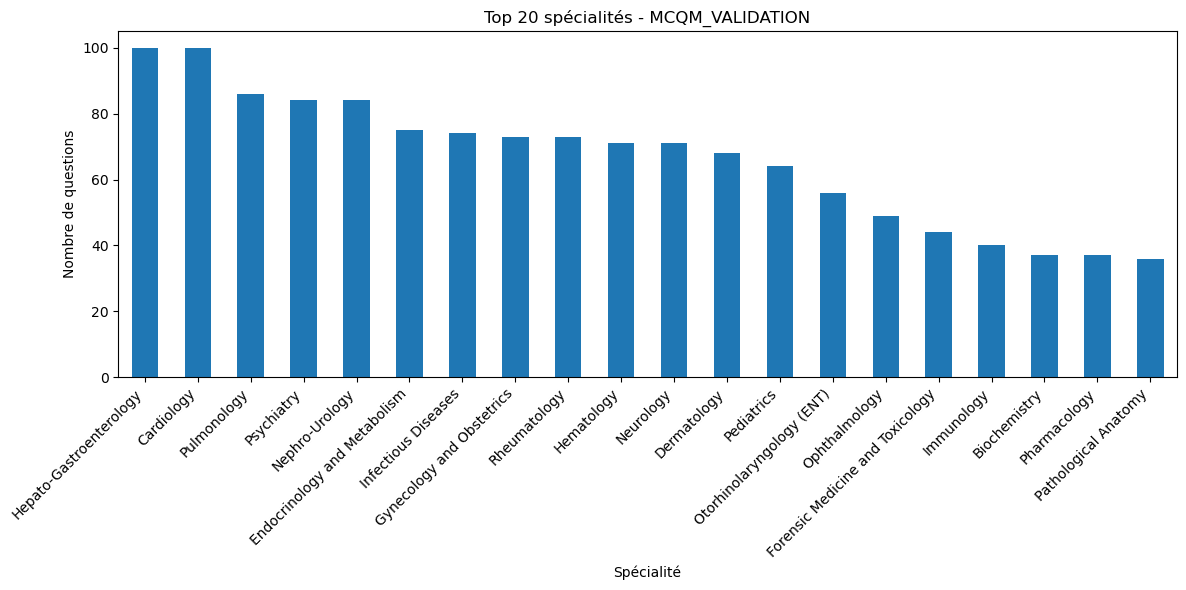


===== Répartition des spécialités MCQM_TEST | colonne: medical_subject =====


medical_subject
Cardiology                          237
Hepato-Gastroenterology             230
Hematology                          216
Nephro-Urology                      213
Pulmonology                         211
Gynecology and Obstetrics           185
Rheumatology                        183
Endocrinology and Metabolism        180
Psychiatry                          165
Dermatology                         159
Neurology                           158
Pediatrics                          145
Infectious Diseases                 140
Otorhinolaryngology (ENT)           137
Ophthalmology                       130
Forensic Medicine and Toxicology    105
Orthopedics                         103
Immunology                           67
Genetics                             67
Epidemiology                         65
Name: count, dtype: int64

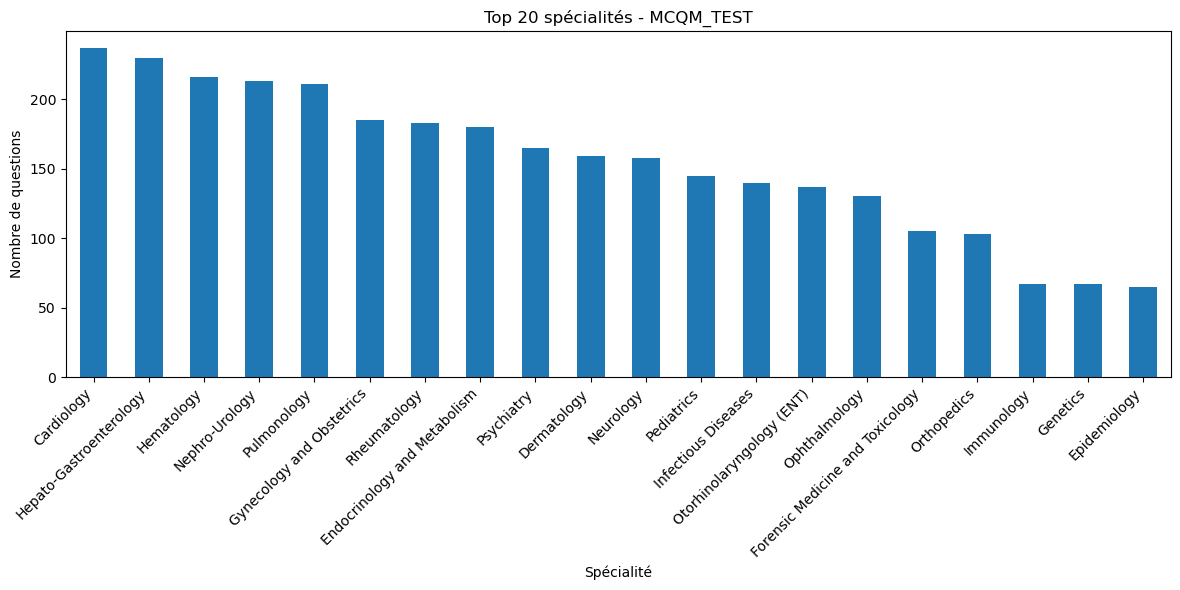


===== Répartition des spécialités OEQ_TEST | colonne: medical_subject =====


medical_subject
Pharmacy                            1544
Pediatric Cardiology                1225
Cardiology                           217
Nephro-Urology                       193
Pulmonology                          184
Intensive Care                       154
Neurology                            150
Gynecology and Obstetrics            149
Otorhinolaryngology (ENT)            126
Hematology                           124
Emergency Medicine                   109
Orthopedics                           93
Infectious Diseases                   88
Forensic Medicine and Toxicology      86
Psychiatry                            80
Hepato-Gastroenterology               68
Genetics                              65
Dermatology                           54
Pediatrics                            47
Rheumatology                          37
Name: count, dtype: int64

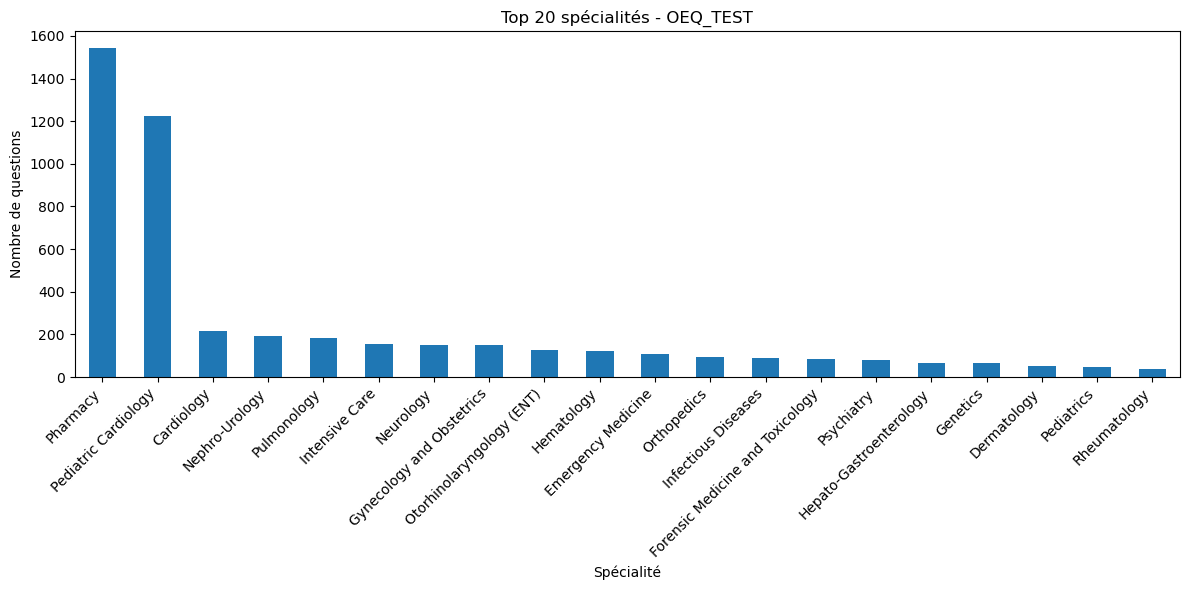

In [29]:
# Répartition des spécialités si la colonne existe

possible_specialty_cols = ["specialty", "subject", "medical_subject", "category"]

for name, df in dfs.items():
    for col in possible_specialty_cols:
        if col in df.columns:
            print(f"\n===== Répartition des spécialités {name.upper()} | colonne: {col} =====")
            display(df[col].value_counts().head(20))
            
            plt.figure(figsize=(12, 6))
            df[col].value_counts().head(20).plot(kind="bar")
            plt.title(f"Top 20 spécialités - {name.upper()}")
            plt.xlabel("Spécialité")
            plt.ylabel("Nombre de questions")
            plt.xticks(rotation=45, ha="right")
            plt.tight_layout()
            plt.show()

In [30]:
# Exploration des réponses
# On exclut les questions ouvertes (oeq) pour l'analyse des réponses
possible_answer_cols = [
    "answer",
    "answers",
    "correct_answer",
    "correct_answers",
    "label"
]

for name, df in dfs.items():
    print(f"\n===== Colonnes de réponse possibles {name.upper()} =====")

    for col in possible_answer_cols:
        if col in df.columns:
            print(f"Colonne détectée : {col}")
            display(df[col].head(10))

            # Ne pas calculer les fréquences pour les questions ouvertes
            if "oeq" not in name.lower():
                display(df[col].value_counts().head(20))


===== Colonnes de réponse possibles MCQU_TRAIN =====
Colonne détectée : correct_answers


0    A
1    C
2    D
3    D
4    A
5    D
6    C
7    C
8    D
9    E
Name: correct_answers, dtype: object

correct_answers
C    2720
D    2409
B    2032
E    1701
A    1251
Name: count, dtype: int64


===== Colonnes de réponse possibles MCQU_VALIDATION =====
Colonne détectée : correct_answers


0    C
1    D
2    E
3    E
4    D
5    B
6    C
7    D
8    C
9    C
Name: correct_answers, dtype: object

...


===== Colonnes de réponse possibles MCQM_TEST =====
Colonne détectée : correct_answers


0    A,B,C,D,E
1        C,D,E
2          B,D
3          B,D
4      A,B,C,D
5          A,E
6          B,E
7        A,C,D
8          A,D
9        A,B,D
Name: correct_answers, dtype: object

correct_answers
A,C          263
B,D          242
B,C          208
A,B          203
C,D          200
A,D          196
A,B,C        163
A,B,C,D,E    153
A,B,C,D      147
A,E          144
A,C,D        140
B,E          125
A,B,D        116
C,E          108
A,B,E        101
B,D,E         99
D,E           97
A,B,C,E       91
B,C,D         89
A,B,D,E       83
Name: count, dtype: int64


===== Colonnes de réponse possibles OEQ_TEST =====
Colonne détectée : answer


0    FC>125bpm\n Terrain : ATCD de BPCO, insuffisan...
1    Insuffisance respiratoire aiguë / exacerbation...
2    Signes d’hypercapnie, pas d’effet du traitemen...
3    En réanimation, car pas de réponse au traiteme...
4    Cocaïne, qui donne un état d’agitation.\n Sign...
5    Recherche de signes d’infection : \n - Points ...
6                            Intoxication à la cocaïne
7    Prise d’anticoagulant\n Age > 60 ans\n Pas de ...
8    Patiente présente des signes d’HTIC\n Signes d...
9    Scanner cérébral sans et avec injection (après...
Name: answer, dtype: object

In [ ]:
# Sauvegarde des données brutes en CSV et Parquet

from pathlib import Path

RAW_DIR = Path("../data/raw/medical")
RAW_DIR.mkdir(parents=True, exist_ok=True)

for name, df in dfs.items():
    df.to_csv(RAW_DIR / f"medical_{name}.csv", index=False)
    df.to_parquet(RAW_DIR / f"medical_{name}.parquet", index=False)

print("Exports terminés.")

Exports terminés.
